# Monthly Job-Advertisement Index Forecasting

Predict the next month's overall index using previously available
observations. Evaluate chronologically using a fixed historical
data snapshot, acknowledging publication delays and revisions.

In [1]:
from pathlib import Path

import pandas as pd

monthly = pd.read_csv(
    Path("../data/processed/monthly_jobs_online.csv"),
    parse_dates=["Date"],
    index_col="Date"
)

monthly.head(10)

,overall_index,reported_yoy_pct,SkilledIndex,UnskilledIndex,Auckland,Wellington,North Island Other,Canterbury,South Island Other,Business services,...,Clerical and Administrative Workers,Sales Workers,Machinery Operators and Drivers,Labourers,Highly-Skilled,Skilled,Semi-Skilled,Low-Skilled,Unskilled,calculated_yoy_pct
Date,,,,,,,,,,,,,,,,,,,,,
2007-05-01,100.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,...,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,NaN
2007-06-01,92.1,0.0,91.5,92.5,91.8,93.5,94.4,94.1,76.6,91.6,...,95.2,93.8,80.2,89.2,91.2,92.8,89.6,92.8,91.2,NaN
2007-07-01,95.7,0.0,95.3,94.9,96.4,95.1,95.5,98.6,84.0,93.2,...,95.9,98.7,92.3,89.5,95.1,93.7,101.7,94.1,97.4,NaN
2007-08-01,103.2,0.0,102.0,103.1,101.2,98.8,113.3,109.5,106.4,96.9,...,103.5,98.6,109.6,110.8,97.7,110.8,111.6,103.1,102.8,NaN
2007-09-01,97.0,0.0,96.7,96.4,93.9,95.1,105.7,103.9,107.4,84.8,...,90.8,96.9,104.7,103.5,91.1,112.1,98.8,95.3,100.2,NaN
2007-10-01,102.2,0.0,104.6,97.0,96.3,101.0,118.6,110.5,119.9,85.9,...,91.4,93.3,108.0,107.0,97.5,126.5,100.8,96.4,99.0,NaN
2007-11-01,101.1,0.0,106.6,90.2,96.2,98.8,118.1,102.9,122.9,88.0,...,87.1,82.5,108.4,99.2,103.2,120.7,94.9,90.4,89.3,NaN
2007-12-01,70.0,0.0,75.0,60.3,65.1,67.8,83.7,71.1,105.8,59.4,...,57.0,55.3,65.4,71.2,75.2,78.7,62.8,60.6,58.9,NaN
2008-01-01,101.8,0.0,101.9,98.6,97.1,97.0,113.3,119.2,117.4,93.1,...,94.3,89.4,109.0,119.5,104.8,91.5,107.2,96.6,105.3,NaN


In [2]:
target = monthly["overall_index"].asfreq("MS")

assert target.notna().all(), "Missing monthly target values"

target.head()

Date
2007-05-01    100.0
2007-06-01     92.1
2007-07-01     95.7
2007-08-01    103.2
2007-09-01     97.0
Freq: MS, Name: overall_index, dtype: float64

### Reserve validation and test periods

In [3]:
train_target = target.loc[:"2022-07-01"]
validation_target = target.loc["2022-08-01":"2024-07-01"]
test_target = target.loc["2024-08-01":"2026-07-01"]

for name, series in {
    "Training": train_target,
    "Validation": validation_target,
    "Test": test_target
}.items():
    print(
        name,
        len(series),
        series.index.min().to_period("M"),
        series.index.max().to_period("M")
    )

Training 183 2007-05 2022-07
Validation 24 2022-08 2024-07
Test 24 2024-08 2026-07


### Create two baseline forecasts

In [4]:
baseline_forecasts = pd.DataFrame({
    "actual": target,
    "last_month_naive": target.shift(1),
    "seasonal_naive": target.shift(12)
})

validation_baselines = baseline_forecasts.loc[
    validation_target.index
].copy()

assert validation_baselines.notna().all().all()

validation_baselines.head()

,actual,last_month_naive,seasonal_naive
Date,,,
2022-08-01,215.5,196.4,168.4
2022-09-01,202.9,215.5,176.8
2022-10-01,190.0,202.9,176.5
2022-11-01,178.7,190.0,184.7
2022-12-01,116.7,178.7,141.1


In [5]:
validation_errors = pd.DataFrame({
    "last_month_naive": (
        validation_baselines["last_month_naive"]
        - validation_baselines["actual"]
    ).abs(),

    "seasonal_naive": (
        validation_baselines["seasonal_naive"]
        - validation_baselines["actual"]
    ).abs()
})

validation_errors.head()

,last_month_naive,seasonal_naive
Date,,
2022-08-01,19.1,47.1
2022-09-01,12.6,26.1
2022-10-01,12.9,13.5
2022-11-01,11.3,6.0
2022-12-01,62.0,24.4


In [6]:
validation_mae = validation_errors.mean().sort_values()

validation_mae.round(2)

last_month_naive    21.50
seasonal_naive      40.21
dtype: float64

In [7]:
validation_rmse = (validation_errors.pow(2).mean()) ** 0.5

In [8]:
baseline_metrics = pd.DataFrame({
    "MAE": validation_mae,
    "RMSE": validation_rmse
}).sort_values("MAE")

baseline_metrics.round(2)

,MAE,RMSE
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Forecasting design and baseline results

The task is to predict the next month's overall job-advertisement
index using observations available through the preceding month,
once published.

Data is split chronologically:
- Training: May 2007–July 2022
- Validation: August 2022–July 2024
- Test: August 2024–July 2026

Validation uses rolling one-month-ahead predictions. Each prediction
may use newly observed prior-month values, but not the target month's
actual value.

| Baseline | Validation MAE | Validation RMSE |
|---|---:|---:|
| Last-month naive | 21.50 | 27.12 |
| Seasonal naive | 40.21 | 43.03 |

Errors are measured in index points. Last-month naive performed
better on both metrics during validation. This does not establish
that seasonality is absent or guarantee future performance.

The test period has not been evaluated. Results use one historical
data snapshot and do not fully reproduce historical release timing
or data revisions.

## Forecasting features

Each row represents the target month. Lag features use only index
values from earlier months. The target is kept separate from inputs.

In [9]:
model_data = pd.DataFrame({"target": target})

for lag in [1, 2, 3, 12]:
    model_data[f"lag_{lag}"] = target.shift(lag)

model_data.head()

,target,lag_1,lag_2,lag_3,lag_12
Date,,,,,
2007-05-01,100.0,NaN,NaN,NaN,NaN
2007-06-01,92.1,100.0,NaN,NaN,NaN
2007-07-01,95.7,92.1,100.0,NaN,NaN
2007-08-01,103.2,95.7,92.1,100.0,NaN
2007-09-01,97.0,103.2,95.7,92.1,NaN


In [10]:
model_data.loc["2022-08-01":"2022-10-01"]

,target,lag_1,lag_2,lag_3,lag_12
Date,,,,,
2022-08-01,215.5,196.4,197.6,213.5,168.4
2022-09-01,202.9,215.5,196.4,197.6,176.8
2022-10-01,190.0,202.9,215.5,196.4,176.5


### Add a rolling-average feature

In [11]:
model_data["rolling_mean_3"] = (
    target.shift(1)
    .rolling(window=3, min_periods=3)
    .mean()
)

model_data["rolling_mean_12"] = (
    target.shift(1)
    .rolling(window=12, min_periods=12)
    .mean()
)

model_data.loc["2022-08-01":"2022-10-01"]

,target,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_12
Date,,,,,,,
2022-08-01,215.5,196.4,197.6,213.5,168.4,202.500000,186.008333
2022-09-01,202.9,215.5,196.4,197.6,176.8,203.166667,189.933333
2022-10-01,190.0,202.9,215.5,196.4,176.5,204.933333,192.108333


### Representing a repeating calendar pattern.

In [12]:
import numpy as np

month_number = model_data.index.month

model_data["month_sin"] = np.sin(
    2 * np.pi * (month_number - 1) / 12
)

model_data["month_cos"] = np.cos(
    2 * np.pi * (month_number - 1) / 12
)

In [13]:
model_data.loc[
    "2022-11-01":"2023-02-01",
    ["month_sin", "month_cos"]
].round(3)

,month_sin,month_cos
Date,,
2022-11-01,-0.866,0.500
2022-12-01,-0.500,0.866
2023-01-01,0.000,1.000
2023-02-01,0.500,0.866


In [14]:
feature_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_12",
    "month_sin",
    "month_cos"
]

incomplete_features = (
    model_data[feature_columns].isna().any(axis=1)
)

print("Rows with incomplete features:", incomplete_features.sum())

assert incomplete_features.iloc[:12].all()
assert not incomplete_features.iloc[12:].any()
assert model_data["target"].notna().all()

model_data.head(15)

Rows with incomplete features: 12


,target,lag_1,lag_2,lag_3,lag_12,rolling_mean_3,rolling_mean_12,month_sin,month_cos
Date,,,,,,,,,
2007-05-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,8.660254e-01,-5.000000e-01
2007-06-01,92.1,100.0,NaN,NaN,NaN,NaN,NaN,5.000000e-01,-8.660254e-01
2007-07-01,95.7,92.1,100.0,NaN,NaN,NaN,NaN,1.224647e-16,-1.000000e+00
2007-08-01,103.2,95.7,92.1,100.0,NaN,95.933333,NaN,-5.000000e-01,-8.660254e-01
2007-09-01,97.0,103.2,95.7,92.1,NaN,97.000000,NaN,-8.660254e-01,-5.000000e-01
2007-10-01,102.2,97.0,103.2,95.7,NaN,98.633333,NaN,-1.000000e+00,-1.836970e-16
2007-11-01,101.1,102.2,97.0,103.2,NaN,100.800000,NaN,-8.660254e-01,5.000000e-01
2007-12-01,70.0,101.1,102.2,97.0,NaN,100.100000,NaN,-5.000000e-01,8.660254e-01
2008-01-01,101.8,70.0,101.1,102.2,NaN,91.100000,NaN,0.000000e+00,1.000000e+00


In [15]:
model_ready = model_data.loc[~incomplete_features].copy()

print("Shape:", model_ready.shape)
print("First month:", model_ready.index.min().to_period("M"))
print("Last month:", model_ready.index.max().to_period("M"))

Shape: (219, 9)
First month: 2008-05
Last month: 2026-07


In [16]:
X = model_ready[feature_columns].copy()
y = model_ready["target"].copy()

X_train = X.loc[:"2022-07-01"]
y_train = y.loc[:"2022-07-01"]

X_validation = X.loc["2022-08-01":"2024-07-01"]
y_validation = y.loc["2022-08-01":"2024-07-01"]

X_test = X.loc["2024-08-01":"2026-07-01"]
y_test = y.loc["2024-08-01":"2026-07-01"]

### The target is not included in X. Otherwise, the model would receive the answer as an input.

In [17]:
splits = {
    "Training": (X_train, y_train),
    "Validation": (X_validation, y_validation),
    "Test": (X_test, y_test)
}

for name, (features, labels) in splits.items():
    assert features.index.equals(labels.index)
    assert features.notna().all().all()
    assert labels.notna().all()

    print(name, "X:", features.shape, "y:", labels.shape)

Training X: (171, 8) y: (171,)
Validation X: (24, 8) y: (24,)
Test X: (24, 8) y: (24,)


### Conclusion: Forecasting feature preparation

Eight features were created: index lags of 1, 2, 3, and 12 months;
trailing means over 3 and 12 months; and sine/cosine encodings
of the target month's calendar position.

Lag and rolling features use only preceding observations. Rolling
means were shifted to exclude the target month's actual value.
Calendar features are known in advance.

The first 12 rows lacked sufficient historical information and were
excluded from the model-ready table without imputing values.

The resulting chronological splits contain:
- Training: 171 observations, May 2008–July 2022
- Validation: 24 observations, August 2022–July 2024
- Test: 24 observations, August 2024–July 2026

Inputs and targets were separated and checked for matching dates
and missing values. Validation and test periods remain unchanged
from the baseline evaluation.

## Linear regression forecasting

Fit a linear regression model on the training period and evaluate
one-month-ahead predictions on the validation period.

In [18]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.29, 0.09,...,-0.53, 5.41, 2.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['lag_1','lag_2','lag_3',...,'rolling_mean_12','month_sin','month_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.148
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


- LinearRegression() creates the model.
- .fit() learns weights that minimize the sum of squared training errors.
- Only training data is used to learn those weights.

### Predict the validation months

In [19]:
linear_validation_predictions = pd.Series(
    linear_model.predict(X_validation),
    index=X_validation.index,
    name="linear_regression"
)

linear_validation_check = pd.DataFrame({
    "actual": y_validation,
    "prediction": linear_validation_predictions
})

linear_validation_check.head(6).round(2)

,actual,prediction
Date,,
2022-08-01,215.5,193.05
2022-09-01,202.9,200.81
2022-10-01,190.0,200.23
2022-11-01,178.7,196.71
2022-12-01,116.7,166.63
2023-01-01,173.0,157.50


### Calculate MAE and RMSE

In [20]:
linear_errors = (
    linear_validation_predictions - y_validation
)

linear_mae = linear_errors.abs().mean()
linear_rmse = (linear_errors.pow(2).mean()) ** 0.5

In [21]:
validation_comparison = baseline_metrics.copy()

validation_comparison.loc["linear_regression"] = {
    "MAE": linear_mae,
    "RMSE": linear_rmse
}

validation_comparison.sort_values("MAE").round(2)

,MAE,RMSE
linear_regression,19.38,23.24
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Inspect the model’s weights

In [22]:
linear_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns,
    name="coefficient"
)

print("Intercept:", round(linear_model.intercept_, 3))
linear_coefficients.round(3)

Intercept: -2.148


lag_1              0.455
lag_2              0.293
lag_3              0.085
lag_12             0.454
rolling_mean_3     0.278
rolling_mean_12   -0.527
month_sin          5.412
month_cos          2.319
Name: coefficient, dtype: float64

In [23]:
reduced_features = [
    column for column in feature_columns
    if column != "rolling_mean_3"
]

linear_reduced = LinearRegression()

linear_reduced.fit(
    X_train[reduced_features],
    y_train
)

reduced_predictions = pd.Series(
    linear_reduced.predict(X_validation[reduced_features]),
    index=X_validation.index
)

reduced_errors = reduced_predictions - y_validation

validation_comparison.loc["linear_regression_reduced"] = {
    "MAE": reduced_errors.abs().mean(),
    "RMSE": (reduced_errors.pow(2).mean()) ** 0.5
}

validation_comparison.sort_values("MAE").round(2)

,MAE,RMSE
linear_regression_reduced,19.38,23.24
linear_regression,19.38,23.24
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Conclusion: Linear regression validation

Linear regression achieved a validation MAE of 19.38 and RMSE of
23.24 index points, outperforming both naive baselines.

Compared with last-month naive, validation MAE decreased by
approximately 9.9% and RMSE by 14.3%.

Feature inspection identified exact redundancy: the three-month
rolling mean equals the average of lags 1, 2, and 3. Removing this
feature produced the same validation metrics at two-decimal precision.
The seven-feature model is retained as the preferred linear regression
specification.

The remaining coefficients should still be interpreted cautiously
because lagged and rolling features are correlated. These validation
results do not establish causal relationships or guarantee better
performance on the held-out test period.

## Ridge regression

Evaluate whether coefficient regularization improves validation
performance. Feature scaling is fitted using training data only.

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train[reduced_features],
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['lag_1','lag_2','lag_3',...,'rolling_mean_12','month_sin','month_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


### Predict validation months

In [25]:
ridge_validation_predictions = pd.Series(
    ridge_model.predict(X_validation[reduced_features]),
    index=X_validation.index,
    name="ridge"
)

ridge_check = pd.DataFrame({
    "actual": y_validation,
    "prediction": ridge_validation_predictions
})

ridge_check.head(6).round(2)

,actual,prediction
Date,,
2022-08-01,215.5,193.53
2022-09-01,202.9,201.12
2022-10-01,190.0,200.48
2022-11-01,178.7,196.52
2022-12-01,116.7,168.93
2023-01-01,173.0,158.79


### Evaluate Ridge

In [26]:
ridge_errors = ridge_validation_predictions - y_validation

ridge_mae = ridge_errors.abs().mean()
ridge_rmse = (ridge_errors.pow(2).mean()) ** 0.5

validation_comparison.loc["ridge_alpha_1"] = {
    "MAE": ridge_mae,
    "RMSE": ridge_rmse
}

validation_comparison.sort_values("MAE").round(2)

,MAE,RMSE
linear_regression_reduced,19.38,23.24
linear_regression,19.38,23.24
ridge_alpha_1,19.56,23.65
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Compare a small set of alpha values

In [27]:
alpha_values = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []

for alpha in alpha_values:
    candidate = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    candidate.fit(
        X_train[reduced_features],
        y_train
    )

    predictions = pd.Series(
        candidate.predict(X_validation[reduced_features]),
        index=X_validation.index
    )

    errors = predictions - y_validation

    ridge_results.append({
        "alpha": alpha,
        "MAE": errors.abs().mean(),
        "RMSE": (errors.pow(2).mean()) ** 0.5
    })

ridge_search = (
    pd.DataFrame(ridge_results)
    .sort_values(["MAE", "alpha"])
    .reset_index(drop=True)
)

ridge_search.round(4)

,alpha,MAE,RMSE
0,100.00,18.8306,24.0148
1,0.01,19.3795,23.2493
2,0.10,19.3884,23.2903
3,1.00,19.5553,23.6478
4,10.00,20.1930,25.0309


### Save the selected model in a variable

In [28]:
best_alpha = float(ridge_search.iloc[0]["alpha"])

best_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

best_ridge_model.fit(
    X_train[reduced_features],
    y_train
)

best_ridge_predictions = pd.Series(
    best_ridge_model.predict(X_validation[reduced_features]),
    index=X_validation.index,
    name="ridge_selected"
)

best_ridge_errors = best_ridge_predictions - y_validation

validation_comparison.loc["ridge_selected"] = {
    "MAE": best_ridge_errors.abs().mean(),
    "RMSE": (best_ridge_errors.pow(2).mean()) ** 0.5
}

print("Selected alpha:", best_alpha)
validation_comparison.sort_values("MAE").round(2)

Selected alpha: 100.0


,MAE,RMSE
ridge_selected,18.83,24.01
linear_regression_reduced,19.38,23.24
linear_regression,19.38,23.24
ridge_alpha_1,19.56,23.65
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Conclusion: Ridge regression

Ridge regression was evaluated using alpha values of 0.01, 0.1, 1,
10, and 100. Each pipeline fitted its feature scaler and model using
training data only.

Alpha 100 achieved the lowest validation MAE among the tested values:
18.83 index points, with RMSE of 24.01.

Reduced linear regression had a higher MAE of 19.38 but a lower RMSE
of 23.24. Ridge was selected as the current leading candidate because
MAE was the predefined primary selection metric.

The test period remains unevaluated.

## Random Forest forecasting

Compare a tree-based model with the linear models and naive baselines,
using the same seven features and chronological validation period.

In [29]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=10,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(
    X_train[reduced_features],
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

### Predict validation months

In [30]:
forest_predictions = pd.Series(
    forest_model.predict(X_validation[reduced_features]),
    index=X_validation.index,
    name="random_forest"
)

forest_check = pd.DataFrame({
    "actual": y_validation,
    "prediction": forest_predictions
})

forest_check.head(6).round(2)

,actual,prediction
Date,,
2022-08-01,215.5,184.35
2022-09-01,202.9,184.35
2022-10-01,190.0,184.35
2022-11-01,178.7,184.35
2022-12-01,116.7,184.11
2023-01-01,173.0,148.11


### Evaluate Random Forest

In [31]:
forest_errors = forest_predictions - y_validation

validation_comparison.loc["random_forest"] = {
    "MAE": forest_errors.abs().mean(),
    "RMSE": (forest_errors.pow(2).mean()) ** 0.5
}

validation_comparison.sort_values("MAE").round(2)

,MAE,RMSE
ridge_selected,18.83,24.01
random_forest,19.13,24.73
linear_regression_reduced,19.38,23.24
linear_regression,19.38,23.24
ridge_alpha_1,19.56,23.65
last_month_naive,21.50,27.12
seasonal_naive,40.21,43.03


### Conclusion: Random Forest validation

A Random Forest with 300 trees, maximum depth 3, and minimum leaf
size 10 achieved validation MAE of 19.13 and RMSE of 24.73 index points.

It outperformed both naïve baselines but did not outperform the
selected Ridge model on either metric. Ridge remains the leading
candidate under the predefined MAE selection criterion.

Repeated predictions across several validation months reflect the
piecewise-constant behaviour of trees. The conservative configuration
limits flexibility, and Random Forest cannot extrapolate beyond the
training target range.

These results apply to this configuration and validation period;
they do not establish that Ridge universally outperforms Random Forest.

### Visualize forecasting errors

In [32]:
validation_plot_data = pd.DataFrame({
    "Actual": y_validation,
    "Ridge": best_ridge_predictions,
    "Last-month naïve": validation_baselines["last_month_naive"]
})

assert validation_plot_data.index.equals(y_validation.index)
assert validation_plot_data.notna().all().all()

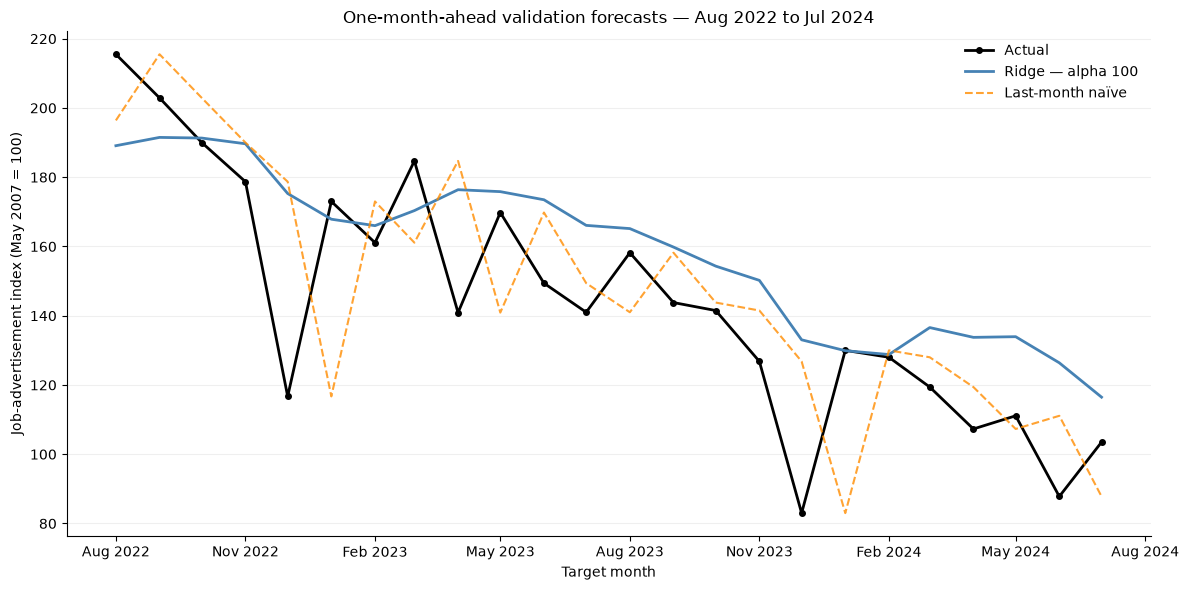

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig_validation, ax_validation = plt.subplots(figsize=(12, 6))

ax_validation.plot(
    validation_plot_data.index,
    validation_plot_data["Actual"],
    label="Actual",
    color="black",
    linewidth=2,
    marker="o",
    markersize=4
)

ax_validation.plot(
    validation_plot_data.index,
    validation_plot_data["Ridge"],
    label="Ridge — alpha 100",
    color="steelblue",
    linewidth=2
)

ax_validation.plot(
    validation_plot_data.index,
    validation_plot_data["Last-month naïve"],
    label="Last-month naïve",
    color="darkorange",
    linestyle="--",
    alpha=0.8
)

ax_validation.set_title(
    "One-month-ahead validation forecasts — Aug 2022 to Jul 2024"
)
ax_validation.set_ylabel("Job-advertisement index (May 2007 = 100)")
ax_validation.set_xlabel("Target month")

ax_validation.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax_validation.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax_validation.legend(frameon=False)
ax_validation.grid(axis="y", alpha=0.2)
ax_validation.spines["top"].set_visible(False)
ax_validation.spines["right"].set_visible(False)

fig_validation.tight_layout()
plt.show()

In [34]:
ridge_diagnostics = pd.DataFrame({
    "actual": y_validation,
    "prediction": best_ridge_predictions
})

ridge_diagnostics["error"] = (
    ridge_diagnostics["prediction"]
    - ridge_diagnostics["actual"]
)

ridge_diagnostics["absolute_error"] = (
    ridge_diagnostics["error"].abs()
)

print(
    "Mean signed error:",
    round(ridge_diagnostics["error"].mean(), 2)
)

print(
    "Overpredictions:",
    (ridge_diagnostics["error"] > 0).sum()
)

print(
    "Underpredictions:",
    (ridge_diagnostics["error"] < 0).sum()
)

print(
    "Exact predictions:",
    (ridge_diagnostics["error"] == 0).sum()
)

Mean signed error: 14.05
Overpredictions: 19
Underpredictions: 5
Exact predictions: 0


In [35]:
largest_ridge_errors = (
    ridge_diagnostics
    .sort_values("absolute_error", ascending=False)
    .head(5)
)

largest_ridge_errors.round(2)

,actual,prediction,error,absolute_error
Date,,,,
2022-12-01,116.7,175.29,58.59,58.59
2023-12-01,83.0,133.04,50.04,50.04
2024-06-01,87.8,126.40,38.60,38.60
2023-04-01,140.9,176.39,35.49,35.49
2024-04-01,107.3,133.75,26.45,26.45


In [36]:
difficult_months = largest_ridge_errors.index

difficult_month_comparison = pd.DataFrame({
    "actual": y_validation.loc[difficult_months],
    "ridge_prediction": best_ridge_predictions.loc[difficult_months],
    "naive_prediction": validation_baselines.loc[
        difficult_months,
        "last_month_naive"
    ]
})

difficult_month_comparison["ridge_absolute_error"] = (
    difficult_month_comparison["ridge_prediction"]
    - difficult_month_comparison["actual"]
).abs()

difficult_month_comparison["naive_absolute_error"] = (
    difficult_month_comparison["naive_prediction"]
    - difficult_month_comparison["actual"]
).abs()

difficult_month_comparison["better_method"] = (
    difficult_month_comparison[
        ["ridge_absolute_error", "naive_absolute_error"]
    ]
    .idxmin(axis=1)
    .map({
        "ridge_absolute_error": "Ridge",
        "naive_absolute_error": "Last-month naïve"
    })
)

difficult_month_comparison.round(2)

,actual,ridge_prediction,naive_prediction,ridge_absolute_error,naive_absolute_error,better_method
Date,,,,,,
2022-12-01,116.7,175.29,178.7,58.59,62.0,Ridge
2023-12-01,83.0,133.04,126.8,50.04,43.8,Last-month naïve
2024-06-01,87.8,126.40,111.1,38.60,23.3,Last-month naïve
2023-04-01,140.9,176.39,184.7,35.49,43.8,Ridge
2024-04-01,107.3,133.75,119.4,26.45,12.1,Last-month naïve


### Conclusion: Validation error diagnostics

The selected Ridge model achieved the lowest overall validation MAE,
but its errors were not directionally balanced. It overpredicted 19 of
24 months and had a mean signed error of +14.05 index points.

Its largest absolute errors occurred in December 2022, December 2023,
June 2024, April 2023, and April 2024. These months involved sharp
movements that the smoother Ridge predictions did not fully capture.

On Ridge's five largest-error months, Ridge outperformed last-month
naïve twice, while last-month naïve performed better three times.
However, these months were selected based on Ridge's errors, so this
subset is diagnostic rather than a separate model-selection test.

The full 24-month validation MAE remains the predefined primary
criterion. Error patterns do not establish their underlying causes.